In [1]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using Tullio  # tullio from Einstein sum notation using Tullio Levi-Civita's Levi Civita ϵ_ijk symbol
using CSV, DataFrames, Dates

In [72]:
theta = transpose(LinRange(0, pi, 3))
phi = 0
m = 3
u0_modes_set = [zeros(1,m); cos.(theta/2); sin.(theta/2).*exp.(im*phi)]

u0_modes_set = u0_modes_set[repeat(.!all(iszero, u0_modes_set, dims=2),1,3)] # remove zero-vector rows
u0_modes_set = reshape(u0_modes_set,:,3)
for i in 1:size(u0_modes_set,1)
    u0_modes_set[i,:] = normalize(u0_modes_set[i,:])
end
u0_modes_set # relative complex amplitudes of sp modes

2×3 Matrix{ComplexF64}:
 0.816497+0.0im  0.57735+0.0im  4.9996e-17+0.0im
      0.0+0.0im  0.57735+0.0im    0.816497+0.0im

In [4]:
t_start0 = time() # for measuring code runtime

### Setting up initial conditions
# simulation params
λ0 = 1550e-9 # m
Nt = 2^8 # 2^10, frequency bins
time_window = 25 # ps, range of pulse
β_order = 2; # mode order: 0, 1, 2, ...

pulse_fwhm = 200e-15 # s
pulse_rep_rate = 80e6 # Hz
P_cont_set = collect(LinRange(0, 400, 20))*1e-3 # W
P_cont_set[1] = 1e-3  # no zero input power (will error)

M = 3 # number of sp modes
theta_set = LinRange(0.1, pi, 20) # relative amplitude angle between mode 2 and 3
phi = 0
# create isnan, iszero exception for u0_modes_set

F = zeros(Float64, length(theta_set), length(P_cont_set), M) # Fano factor, [relative amp, power, spatial mode]

for (i, theta) in enumerate(theta_set)
    u0_modes = normalize([0, cos(theta/2), sin(theta/2)*exp(im*phi)]) # relative complex amplitudes of sp modes
    println("|u0_modes|^2 = ", abs2.(u0_modes)) # print new line, element-wise abs^2
    
    sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order); # sim = dictionary of params from inputs from helpers.jl

    # fiber params
    L_fiber = 1 # m
    radius = 62.5/2 # micron
    core_NA = 0.275
    alpha = 2.08 # GRIN fiber parabola param.
    nx = 200 # 200 # spatial dir resolution
    fiber_fname = @sprintf("../fibers/DispersiveFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_Nt=%d_time_window=%.2fps_nx=%d_Nbeta=%d.npz", radius, M, 1e6*λ0,
        Nt, time_window, nx, β_order+1)
    fiber = MultiModeNoise.get_disp_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname);
    fiber["zsave"] = LinRange(0, L_fiber, 2); # resolution in z, =linspace(start,stop,length) but lazy until collected
    # fiber["zsave"] = nothing # no propagation results save in the mid points

    for (j, P_cont) in enumerate(P_cont_set)
        t_start = time() # for measuring code runtime

        ### Fiber propagation through L
        ut0, uω0 = MultiModeNoise.get_initial_state(u0_modes, P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]
        sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim); # sol_disp_mmf = dictionary of solutions (uw, μw, νw), in simulate_mmf.jl
        uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]
        FF, ZZ = MultiModeNoise.meshgrid(sim["fs"] .- sim["f0"], fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

        ### Spatial-mode-dependent noise value (frequency summed)
        ∂Xkl∂u = zeros(ComplexF64, M, M, Nt, M)

        for k in 1:M
            λωL = 2 * uω_z[end,:,k] * diagm(ones(M))[:,k]'
            sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim)
            ∂Xkl∂u[k,k,:,:] = -0.5*sqrt(sim["ε"]*Nt)*conj.(sol_adjoint_disp_mmf(0))
            # print(@sprintf("\rprogress: %d/%d", k, M)); flush(stdout)
        end

        ε = sim["ε"] # Δt/(ħω0)
        U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
        # δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1) # why this? = δF_in_ω=999 * max-normalized for spatial-mode #1
        δF_in_ω = zeros(Float64, Nt) # no noise for input laser = shot-noise-limited
        # δF_in_ω = ones(Float64, Nt) # thermal source
        uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]

        # noise plotting for mode m
        for m in 1:M # spatial mode #, m ∈ [1, M]
            uωf_m = uωf[:,m] # intensity for mode m
            @tullio X = Nt * ε * abs2.(uωf_m[ω]) # X = n = number of photons = photon-number normalized |electric field|^2
            # @tullio X = Nt * ε * conj(uωf_m[ω]) * uωf_m[ω]
            ∂Xmm∂u = ∂Xkl∂u[m,m,:,:]
            var_X = MultiModeNoise.compute_noise_map_modem_fsum(X, ∂Xmm∂u, U, δF_in_ω); # var_X = noise = (Δn)^2
            F[i,j,m] = MultiModeNoise.lin_to_dB.(var_X./X)
        end
        # println("\nF = ", F[i,:], " dB") # print Fano factors in dB for each spatial mode
        # println("sum(F) = ", sum(F), " dB")
        t_end = time()
        print(@sprintf("\rprogress: %d/%d, time: %.2f s", j*(i-1)+j, prod(size(F))/M, t_end - t_start)); flush(stdout)
    end
end

t_end0 = time()
println("\nTotal runtime: ", t_end0 - t_start0, " s")

|u0_modes|^2 = [0.0, 0.997502082639013, 0.002497917360987117]
Load fiber params
progress: 20/400, time: 4.73 s|u0_modes|^2 = [0.0, 0.9831842126259134, 0.016815787374086663]
Load fiber params
progress: 40/400, time: 4.77 s|u0_modes|^2 = [0.0, 0.9565102836800564, 0.04348971631994359]
Load fiber params
progress: 60/400, time: 4.88 s|u0_modes|^2 = [0.0, 0.9181624055008303, 0.08183759449917011]
Load fiber params
progress: 80/400, time: 4.88 s|u0_modes|^2 = [0.0, 0.8691212157629494, 0.13087878423705063]
Load fiber params
progress: 100/400, time: 4.81 s|u0_modes|^2 = [0.0, 0.8106408031032116, 0.1893591968967884]
Load fiber params
progress: 120/400, time: 4.88 s|u0_modes|^2 = [0.0, 0.7442166373783587, 0.25578336262164125]
Load fiber params
progress: 140/400, time: 4.88 s|u0_modes|^2 = [0.0, 0.6715473272862933, 0.32845267271370704]
Load fiber params
progress: 160/400, time: 4.73 s|u0_modes|^2 = [0.0, 0.5944911832904726, 0.4055088167095275]
Load fiber params
progress: 180/400, time: 4.83 s|u0_mo

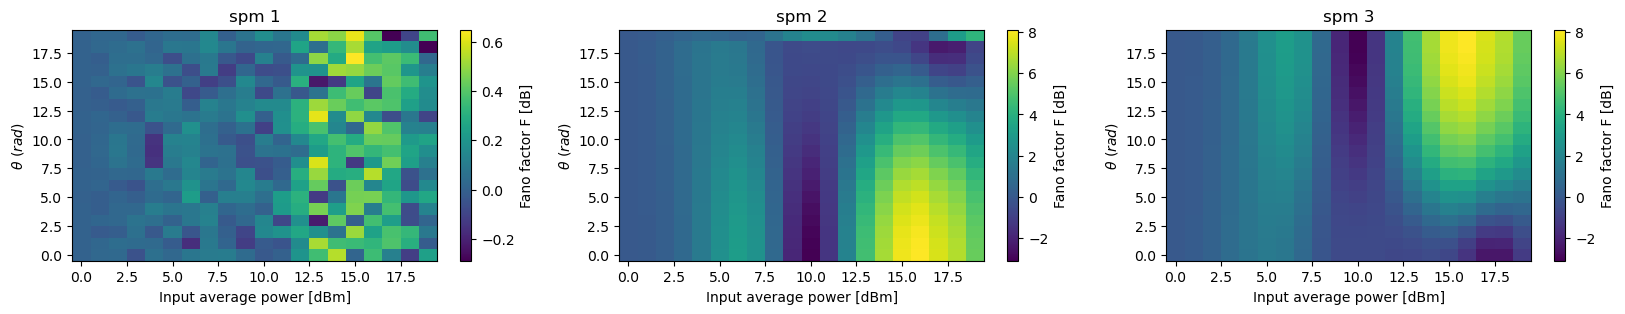

In [5]:
### plotting Fano factors [dB] vs. P_input [dBm]
# P_cont_set_dB = MultiModeNoise.lin_to_dB.(P_cont_set/1e-3)

fig, axs = subplots(1, M, figsize=(20,3))
for m in 1:M 
    im = axs[m].pcolormesh(F[:,:,m], shading="nearest") # plotting for every sp mode
    fig.colorbar(im, ax=axs[m], label="Fano factor F [dB]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
    axs[m].set_title(@sprintf("spm %d",m))
    # axs[m].set_xlim(-20,20)
    axs[m].set_xlabel("Input average power [dBm]")
    axs[m].set_ylabel(L"\theta\ (rad)")
end

# ### plotting Fano factors [dB] vs. P_input [mW]
# P_cont_set_mW = P_cont_set*1e3

# fig, axs = subplots(1, M, figsize=(20,3))
# for m in 1:M 
#     im = axs[m].pcolormesh(F[:,:,m], shading="nearest") # plotting for every sp mode
#     fig.colorbar(im, ax=axs[m], label="Fano factor F [dB]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
#     axs[m].set_title(@sprintf("spm %d",m))
#     # axs[m].set_xlim(-20,20)
#     axs[m].set_xlabel("Input average power [mW]")
#     axs[m].set_ylabel(L"\theta\ (rad)")
# end

show()

# to dos: save u0_modes as well; save in between loops w "for m in ..."

In [ ]:
### saving F vs. P data to .csv file
# using Pkg; Pkg.add("CSV"); Pkg.add("DataFrames"); Pkg.add("Dates") # if not installed
using CSV, DataFrames, Dates

df = DataFrame(power_mw = P_cont_set*1e3) # ensure array, convert to mW
for m in 1:M
    df[!, Symbol("F_spm_$(m)_db")] = F[:,m]
end

path = "\\\\files.cornell.edu\\EN\\riveralab\\Data\\mmf-spmode-squeezing\\"
filename = path*Dates.format(Dates.now(), "yymmdd_")*"data_f_vs_p_0-400mw_$(M)modes.csv" # full filename (path, file)
write(filename, @sprintf("spm_input = %s\n", round.(u0_modes, digits=3)))
CSV.write(filename, df, append=true) # save to .csv
# df2 = CSV.read("F_vs_P.csv", DataFrame)        # read back to verify
# P_loaded_mW = df2.Power_mW
# F_loaded = Matrix(df2[:, 2:end])
# println("Wrote and read back: ", size(df2), "  (rows,cols)")

"\\\\files.cornell.edu\\EN\\riveralab\\Data\\mmf-spmode-squeezing\\251124_data_f_vs_p_0-400mW_10modes.csv"

In [10]:
using Pkg; Pkg.status()

Project MultiModeNoise v1.0.0-DEV
Status `C:\Users\EN-AEP-RiveraLab\Documents\Code sanctuary\dk932\mmf-spmode-squeezing\Project.toml`
  [7d9fca2a] Arpack v0.5.4
  [336ed68f] CSV v0.10.15
  [a93c6f00] DataFrames v1.8.1
  [0c46a032] DifferentialEquations v7.17.0
  [7a1cc6ca] FFTW v1.10.0
  [26cc04aa] FiniteDifferences v0.12.33
  [bdcacae8] LoopVectorization v0.12.173
  [15e1cf62] NPZ v0.4.3
  [d330b81b] PyPlot v2.11.6
  [bc48ee85] Tullio v0.3.8
  [37e2e46d] LinearAlgebra v1.12.0
  [2f01184e] SparseArrays v1.12.0
